# Random Cube Visualizer (1995) with Official LULC Classes

This notebook picks a random cube from `../data/dataset/1995`, prints all metadata, and visualizes imagery/mask using the Decadal LULC India class legend.

Class sources used in `src/lulc_classes.py`:
- ORNL DAAC Decadal LULC India guide
- Remote Sensing (2015) 7(3):2401-2430

📦 INSPECTING CUBE: cube_315.npz
🔑 Keys inside NPZ: ['pixels', 'mask', 'lat_norm', 'lon_norm', 'week_norm', 'hour_norm']
📏 Pixels shape (Bands, H, W): (6, 256, 256)
📏 Mask shape (H, W):          (256, 256)



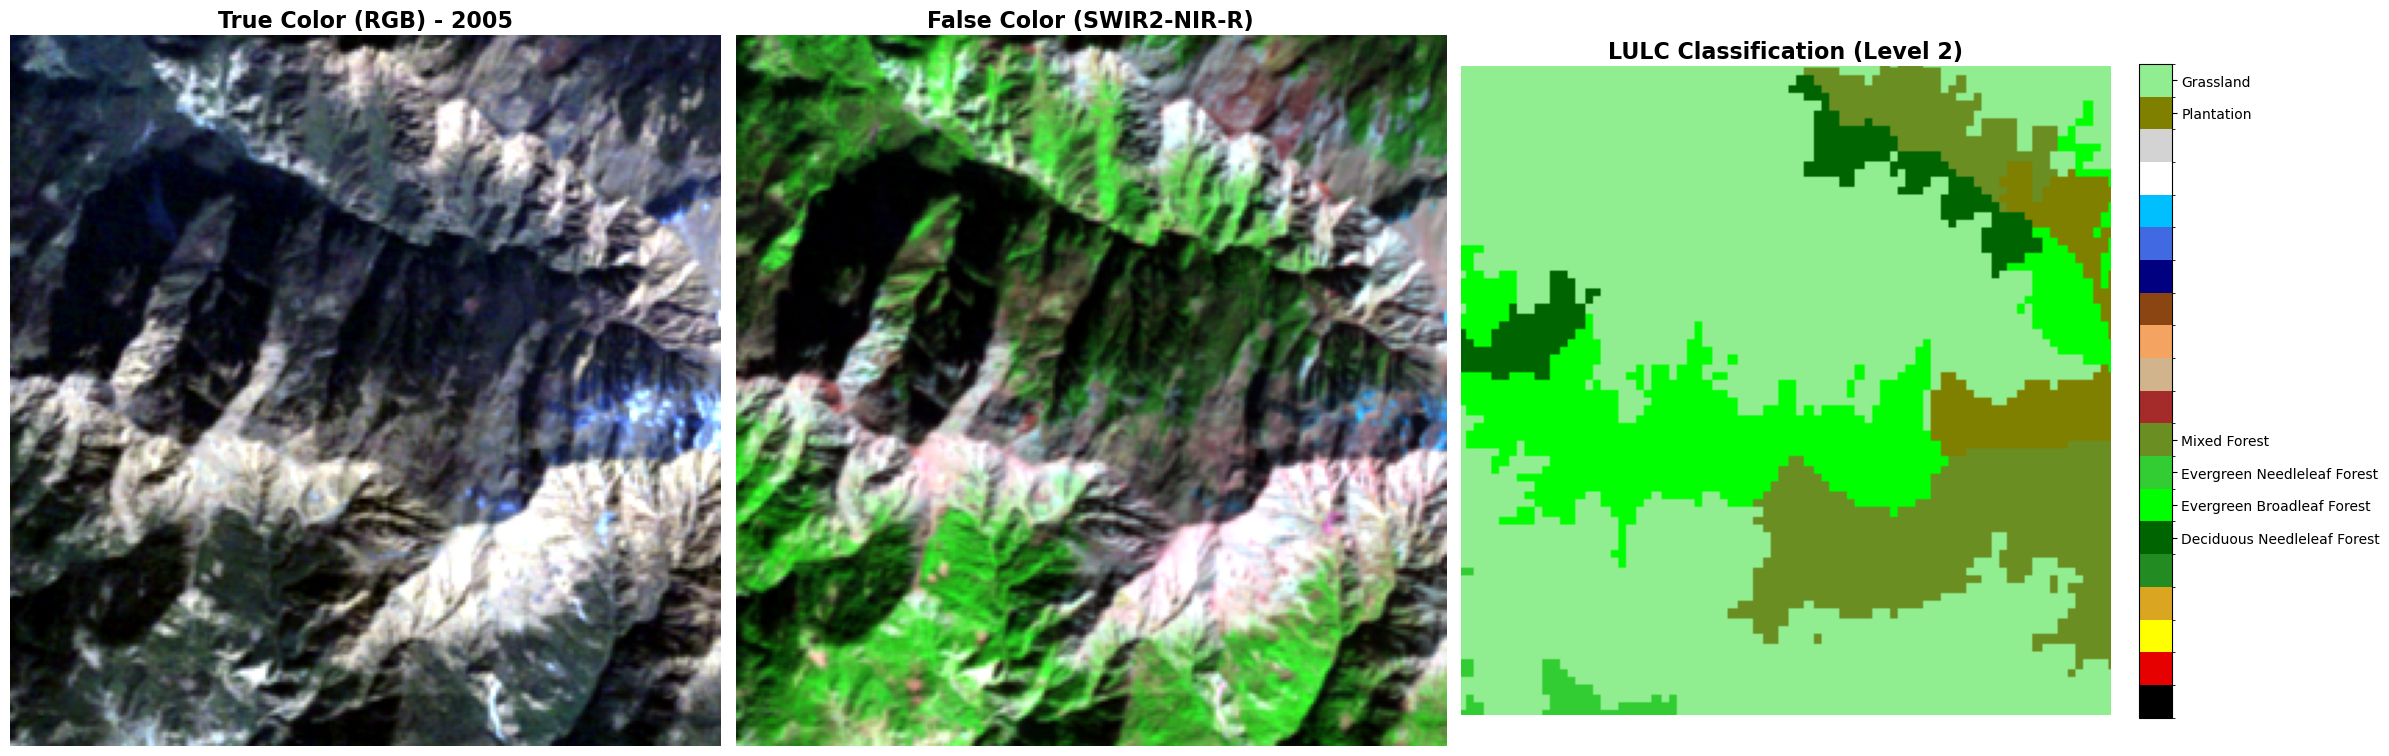


📊 COMPOSITION ANALYSIS: 2005


,ID,Category (L1),Class (L2),Pixels,% Cover
0,19,Grassland,Grassland,39279,59.93
1,6,Forest,Evergreen Broadleaf Forest,10218,15.59
2,8,Forest,Mixed Forest,9765,14.90
3,18,Plantation,Plantation,2888,4.41
4,5,Forest,Deciduous Needleleaf Forest,2795,4.26
5,7,Forest,Evergreen Needleleaf Forest,591,0.90


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path

# --- 1. LOAD CUBE & EXTRACT YEAR FROM PATH ---
# Replace this with the actual path to one of your cubes
selected_cube_path = "../data/dataset/2005/cube_315.npz" 
cube = np.load(selected_cube_path)

# Extract year from directory name (e.g., '../1995/cube_0.npz' -> '1995')
year_label = Path(selected_cube_path).parent.name 

# --- NEW: PRINT KEYS AND SHAPES ---
print("="*50)
print(f"📦 INSPECTING CUBE: {Path(selected_cube_path).name}")
print(f"🔑 Keys inside NPZ: {list(cube.keys())}")

pixels = cube['pixels']
mask = cube['mask'].squeeze()

print(f"📏 Pixels shape (Bands, H, W): {pixels.shape}")
print(f"📏 Mask shape (H, W):          {mask.shape}")
print("="*50 + "\n")
# ----------------------------------

# --- 2. LULC MAPPING (Level 1, Level 2) ---
LULC_CLASS_MAP = {
    0: ("No Data", "No Data"),
    1: ("Built-up Land", "Built-up Land"),
    2: ("Agricultural Land", "Crop land"),
    3: ("Agricultural Land", "Fallow land"),
    4: ("Forest", "Deciduous Broadleaf Forest"),
    5: ("Forest", "Deciduous Needleleaf Forest"),
    6: ("Forest", "Evergreen Broadleaf Forest"),
    7: ("Forest", "Evergreen Needleleaf Forest"),
    8: ("Forest", "Mixed Forest"),
    9: ("Barren Land", "Barren rocky"),
    10: ("Barren Land", "Scrub land"),
    11: ("Barren Land", "Sandy area"),
    12: ("Barren Land", "Barren/unculturable/wasteland"),
    13: ("Water", "Permanent wetland"),
    14: ("Water", "Seasonal wetland"),
    15: ("Water", "Water bodies"),
    16: ("Snow and Ice", "Snow and Ice"),
    17: ("Open Area", "Open Area"),
    18: ("Plantation", "Plantation"),
    19: ("Grassland", "Grassland"),
}

# Standardized NRSC-style colors for the 20 classes
class_colors = [
    "#000000", "#E60000", "#FFFF00", "#DAA520", "#228B22", 
    "#006400", "#00FF00", "#32CD32", "#6B8E23", "#A52A2A", 
    "#D2B48C", "#F4A460", "#8B4513", "#000080", "#4169E1", 
    "#00BFFF", "#FFFFFF", "#D3D3D3", "#808000", "#90EE90"
]

# --- 3. PIXEL STATISTICS ---
classes, counts = np.unique(mask, return_counts=True)
class_rows = []
for cid, count in zip(classes, counts):
    lvl1, lvl2 = LULC_CLASS_MAP.get(int(cid), ("Unknown", "Unknown")) 
    class_rows.append({
        'ID': int(cid),
        'Category (L1)': lvl1,
        'Class (L2)': lvl2,
        'Pixels': int(count),
        '% Cover': round(100.0 * count / mask.size, 2)
    })
stats_df = pd.DataFrame(class_rows).sort_values('Pixels', ascending=False).reset_index(drop=True)

# --- 4. VISUALIZATION ---
def robust_stretch(img):
    low, high = np.nanpercentile(img, (2, 98))
    return np.clip((img - low) / (high - low), 0, 1) if high > low else img

# [0:Red, 1:Green, 2:Blue, 3:NIR, 4:SWIR1, 5:SWIR2]
rgb_img = np.dstack([robust_stretch(pixels[i]) for i in [0, 1, 2]])
fcc_img = np.dstack([robust_stretch(pixels[i]) for i in [5, 3, 0]]) # SWIR2-NIR-Red

fig, axes = plt.subplots(1, 3, figsize=(24, 8), dpi=100)

# A) RGB
axes[0].imshow(rgb_img)
axes[0].set_title(f"True Color (RGB) - {year_label}", fontsize=16, fontweight='bold')
axes[0].axis('off')

# B) FCC (Better for Vegetation/Soil contrast)
axes[1].imshow(fcc_img)
axes[1].set_title("False Color (SWIR2-NIR-R)", fontsize=16, fontweight='bold')
axes[1].axis('off')

# C) LULC Mask
cmap = ListedColormap(class_colors)
norm = BoundaryNorm(np.arange(-0.5, 20.5, 1), cmap.N)
im_mask = axes[2].imshow(mask, cmap=cmap, norm=norm)
axes[2].set_title("LULC Classification (Level 2)", fontsize=16, fontweight='bold')
axes[2].axis('off')

# Legend for present classes
present_ids = sorted([int(c) for c in classes if c in LULC_CLASS_MAP])
cbar = plt.colorbar(im_mask, ax=axes[2], fraction=0.046, pad=0.04, ticks=present_ids)
cbar.ax.set_yticklabels([LULC_CLASS_MAP[cid][1] for cid in present_ids])

plt.tight_layout()
plt.show()

# Display Statistics
print(f"\n📊 COMPOSITION ANALYSIS: {year_label}")
display(stats_df)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path

# --- 1. LOAD CUBE & EXTRACT YEAR FROM PATH ---
# Replace this with the actual path to one of your cubes
selected_cube_path = "../../data/embeddings/2005/emb_cube_315.npz" 
cube = np.load(selected_cube_path)

# Extract year from directory name (e.g., '../1995/cube_0.npz' -> '1995')
year_label = Path(selected_cube_path).parent.name 

# --- NEW: PRINT KEYS AND SHAPES ---
print("="*50)
print(f"📦 INSPECTING CUBE: {Path(selected_cube_path).name}")
print(f"🔑 Keys inside NPZ: {list(cube.keys())}")

#pixels = cube['pixels']
mask = cube['mask'].squeeze()
embeddings = cube['embeddings']

print(f"📏 Embeddings shape (H, W, D): {embeddings.shape}")
print(f"📏 Mask shape (H, W):          {mask.shape}")
print("="*50 + "\n")

📦 INSPECTING CUBE: emb_cube_315.npz
🔑 Keys inside NPZ: ['embeddings', 'mask']
📏 Embeddings shape (H, W, D): (257, 1024)
📏 Mask shape (H, W):          (256, 256)



In [7]:
embeddings_seq = embeddings[1:,:].reshape(16,16,1024)

In [8]:
embeddings_seq.shape

(16, 16, 1024)